In [2]:
!pip3 install pandas requests streamlit matplotlib vaderSentiment transformers torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 603.5 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 30.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 48.5 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 38.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 35.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 23.3 MB/s eta 0:00:0000

In [4]:
#Importing all our libraries
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
from datetime import datetime

# Testing
analyzer = SentimentIntensityAnalyzer()
test = analyzer.polarity_scores("machine learning is love!")
print(test)

{'neg': 0.0, 'neu': 0.4, 'pos': 0.6, 'compound': 0.6696}


In [6]:
import requests

API_KEY = "f033654b1cbf47fa8e4bf367e5b52f21"

#Fetching live headlines on any topic
def get_headlines(topic):
    url = f"https://newsapi.org/v2/everything?q={topic}&language=en&sortBy=publishedAt&pageSize=20&apiKey={API_KEY}"
    response = requests.get(url)
    data = response.json()
    
    # Extracting just the headlines
    headlines = [article['title'] for article in data['articles']]
    return headlines

#Testing
headlines = get_headlines("artificial intelligence")
for h in headlines:
    print(h)

Pentagon's chief tech officer says he clashed with AI company Anthropic over autonomous warfare
AI, EV boom creating new waste problem: what happens to all the lithium batteries?
US to send anti-drone system to the Mideast after successful use in Ukraine, officials say
Pentagon's chief tech officer says he clashed with AI company Anthropic over autonomous warfare
Oracle and OpenAI drop Texas data centre expansion plan: Bloomberg
US draws up strict new AI guidelines amid Anthropic clash: FT
Anthropic launches Claude Marketplace with third-party cloud services
Have you noticed your AI assistant’s favourite words?
US draws up strict new AI guidelines amid Anthropic clash: Report
Seth MacFarlane Said “To Hell With It,” Using AI In ‘Ted’ To Transform Into Bill Clinton: “It Was The Only Way”
Moral Uncertainty Engines
Build an AI Content Marketing Workflow for B2B (2026)
Look out for outdated video of Iranian aircraft being bombed
America’s Gulf war machine: What we know about the US military

In [7]:
#Running sentiment on every headline
def analyze_headlines(headlines):
    results = []
    for headline in headlines:
        score = analyzer.polarity_scores(headline)
        results.append({
            'headline': headline,
            'negative': score['neg'],
            'neutral': score['neu'],
            'positive': score['pos'],
            'compound': score['compound'],
            'sentiment': 'Positive' if score['compound'] > 0.05 else ('Negative' if score['compound'] < -0.05 else 'Neutral')
        })
    return pd.DataFrame(results)

#Testing
df = analyze_headlines(headlines)
print(df[['headline', 'sentiment', 'compound']])

                                             headline sentiment  compound
0   Pentagon's chief tech officer says he clashed ...  Negative   -0.2960
1   AI, EV boom creating new waste problem: what h...  Negative   -0.5106
2   US to send anti-drone system to the Mideast af...  Positive    0.5859
3   Pentagon's chief tech officer says he clashed ...  Negative   -0.2960
4   Oracle and OpenAI drop Texas data centre expan...  Negative   -0.2732
5   US draws up strict new AI guidelines amid Anth...   Neutral    0.0000
6   Anthropic launches Claude Marketplace with thi...   Neutral    0.0000
7   Have you noticed your AI assistant’s favourite...   Neutral    0.0000
8   US draws up strict new AI guidelines amid Anth...   Neutral    0.0000
9   Seth MacFarlane Said “To Hell With It,” Using ...  Negative   -0.6808
10                          Moral Uncertainty Engines  Negative   -0.3400
11  Build an AI Content Marketing Workflow for B2B...   Neutral    0.0000
12  Look out for outdated video of Ira

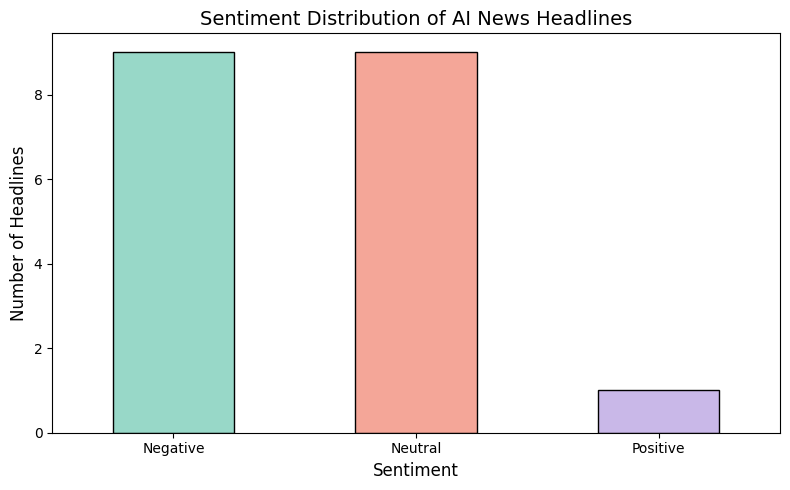


Total headlines analyzed: 19
Positive: 1
Negative: 9
Neutral: 9


In [10]:
#Visualizing sentiment distribution
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(8, 5))
colors = ['#98D8C8', '#F4A698', '#C9B8E8']  # green, red, grey
sentiment_counts.plot(kind='bar', color=colors, edgecolor='black')

plt.title('Sentiment Distribution of AI News Headlines', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Headlines', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nTotal headlines analyzed: {len(df)}")
print(f"Positive: {sentiment_counts.get('Positive', 0)}")
print(f"Negative: {sentiment_counts.get('Negative', 0)}")
print(f"Neutral: {sentiment_counts.get('Neutral', 0)}")

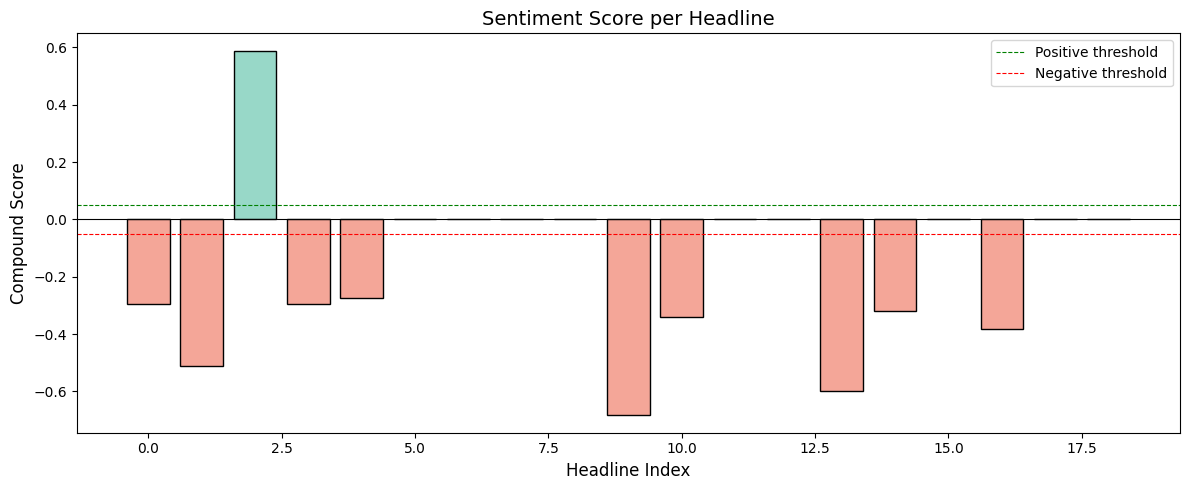

In [11]:
# Compound score chart - sentiment strength per headline
plt.figure(figsize=(12, 5))
colors = ['#98D8C8' if c > 0.05 else '#F4A698' if c < -0.05 else '#C9B8E8' 
          for c in df['compound']]

plt.bar(range(len(df)), df['compound'], color=colors, edgecolor='black')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.axhline(y=0.05, color='green', linestyle='--', linewidth=0.8, label='Positive threshold')
plt.axhline(y=-0.05, color='red', linestyle='--', linewidth=0.8, label='Negative threshold')

plt.title('Sentiment Score per Headline', fontsize=14)
plt.xlabel('Headline Index', fontsize=12)
plt.ylabel('Compound Score', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
!pip3 install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.9/168.9 kB 2.7 MB/s eta 0:00:00 0:00:01

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
